# 03 — Model Training

Build and train the BiLSTM model.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import config
from src.preprocessing import load_and_preprocess
from src.tokenizer_utils import build_tokenizer, save_tokenizer, texts_to_padded_sequences, get_vocab_size
from src.model import build_bilstm_model
from sklearn.model_selection import train_test_split

c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.10) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## 1. Prepare data

In [2]:
df = load_and_preprocess()
X = df['cleaned_text'].values
y = df['label'].values
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

tokenizer    = build_tokenizer(X_train_raw.tolist())
save_tokenizer(tokenizer)
X_train      = texts_to_padded_sequences(tokenizer, X_train_raw.tolist())
X_test       = texts_to_padded_sequences(tokenizer, X_test_raw.tolist())
vocab_size   = get_vocab_size(tokenizer)
print("Ready. vocab_size =", vocab_size)

2026-06-30 03:07:38 | INFO | preprocessing | Loading dataset from c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\dataset\spam.csv
2026-06-30 03:07:38 | INFO | preprocessing | Loaded 5169 rows  |  spam=653  ham=4516
2026-06-30 03:07:38 | INFO | preprocessing | Encoding labels …
2026-06-30 03:07:38 | INFO | preprocessing | Cleaning text (this may take a moment) …
2026-06-30 03:07:38 | INFO | preprocessing | Preprocessing complete.
2026-06-30 03:07:38 | INFO | tokenizer_utils | Fitting tokenizer on 4135 texts  (vocab_size=10000, oov='<OOV>') …
2026-06-30 03:07:39 | INFO | tokenizer_utils | Vocabulary size (incl. OOV+PAD): 6074
2026-06-30 03:07:39 | INFO | tokenizer_utils | Tokenizer saved → c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\models\tokenizer.pkl
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File

Ready. vocab_size = 6074


## 2. Build model

In [3]:
model = build_bilstm_model(vocab_size=vocab_size)
model.summary()

2026-06-30 03:07:39 | INFO | model | Building BiLSTM model  vocab=6074  emb=64  lstm_units=64  lr=0.0010


c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


2026-06-30 03:07:39 | INFO | model | Model: "BiLSTM_SpamDetector"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (D

Model: "BiLSTM_SpamDetector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout                 │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm (Bidirectional)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 3. Train

In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint(config.MODEL_PATH, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train,
    epochs=config.EPOCHS,
    batch_size=config.BATCH_SIZE,
    validation_split=config.VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8719 - loss: 0.3969
Epoch 1: val_accuracy improved from None to 0.98309, saving model to c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\models\bilstm_spam_model.h5


117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9089 - loss: 0.2684 - val_accuracy: 0.9831 - val_loss: 0.0698 - learning_rate: 0.0010
Epoch 2/10
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9816 - loss: 0.0628
Epoch 2: val_accuracy improved from 0.98309 to 0.98792, saving model to c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\models\bilstm_spam_model.h5


117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9839 - loss: 0.0564 - val_accuracy: 0.9879 - val_loss: 0.0524 - learning_rate: 0.0010
Epoch 3/10
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.9927 - loss: 0.0229
Epoch 3: val_accuracy did not improve from 0.98792
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.9922 - loss: 0.0257 - val_accuracy: 0.9879 - val_loss: 0.0472 - learning_rate: 0.0010
Epoch 4/10
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9970 - loss: 0.0087
Epoch 4: val_accuracy improved from 0.98792 to 0.99034, saving model to c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\models\bilstm_spam_model.h5


117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.9973 - loss: 0.0111 - val_accuracy: 0.9903 - val_loss: 0.0499 - learning_rate: 0.0010
Epoch 5/10
116/117 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9978 - loss: 0.0063
Epoch 5: val_accuracy did not improve from 0.99034
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9984 - loss: 0.0069 - val_accuracy: 0.9903 - val_loss: 0.0470 - learning_rate: 0.0010
Epoch 6/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 0.0011  
Epoch 6: val_accuracy did not improve from 0.99034
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.9995 - loss: 0.0028 - val_accuracy: 0.9879 - val_loss: 0.0653 - learning_rate: 0.0010
Epoch 7/10
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9990 - loss: 0.0022
Epoch 7: val_accuracy did not improve from 0.99034

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 0.9995 - loss: 0.0017 - val

## 4. Training curves

2026-06-30 03:08:35 | INFO | evaluate | Training history plot saved → c:\Users\suppa\Downloads\Spam_Email_Detection_Using_BiLSTM\saved_plots\training_history.png
--- Logging error ---
Traceback (most recent call last):
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\logging\__init__.py", line 1103, in emit
    stream.write(msg + self.terminator)
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
UnicodeEncodeError: 'charmap' codec can't encode character '\u2192' in position 68: character maps to <undefined>
Call stack:
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\suppa\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "C:\Users\suppa\AppData\Roaming\Pyth

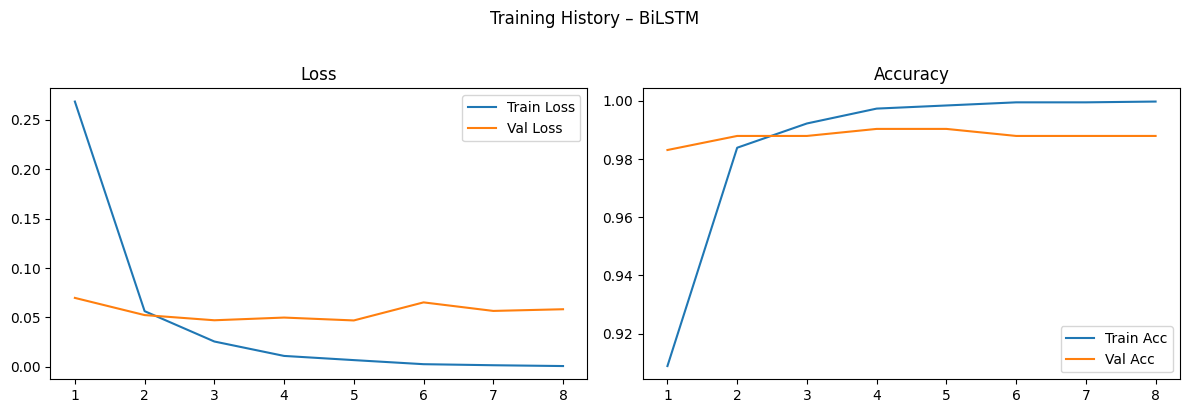

In [5]:
import matplotlib.pyplot as plt
from src.evaluate import plot_training_history
plot_training_history(history)